# Fine-tuned T5 vs Off-the-shelf Pegasus — Paraphrase Comparison

Comparing **your fine-tuned T5-small** against an **off-the-shelf Pegasus paraphraser** (`tuner007/pegasus_paraphrase`).

Why off-the-shelf Pegasus? It's already a fine-tuned paraphrase model from its author, and at ~570M params it OOMs when fine-tuned further on a 24 GB Mac. The comparison axis is actually more interesting this way: *small model + your data* vs *large model + general data*.

**Prereqs:**
- T5 checkpoint at `../checkpoints/t5-small-paraphrase`
- Internet access for the first Pegasus load (subsequent runs use the HF cache)
- For metrics chart: run `python src/evaluate.py --model <model> ...` first to produce `eval_validation.summary.json`

In [1]:
import os, sys, time, json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
T5_PATH          = REPO / 'checkpoints' / 't5-small-paraphrase'
PEGASUS_MODEL_ID = 'tuner007/pegasus_paraphrase'   # off-the-shelf

def pick_device():
    if torch.backends.mps.is_available(): return 'mps'
    if torch.cuda.is_available():         return 'cuda'
    return 'cpu'

DEVICE = pick_device()
print('Device:        ', DEVICE)
print('T5 path exists:', T5_PATH.exists())
print('Pegasus model: ', PEGASUS_MODEL_ID, '(loaded from HF cache)')

Device:         mps
T5 path exists: True
Pegasus model:  tuner007/pegasus_paraphrase (loaded from HF cache)


In [2]:
def load_model(path_or_id):
    tok = AutoTokenizer.from_pretrained(path_or_id)
    mdl = AutoModelForSeq2SeqLM.from_pretrained(path_or_id).to(DEVICE)
    mdl.eval()
    return mdl, tok

models = {}
if T5_PATH.exists():
    print('Loading fine-tuned T5...')
    models['T5 (fine-tuned)'] = load_model(T5_PATH)
else:
    print(f'WARNING: {T5_PATH} not found — train T5 first or change T5_PATH.')

print('Loading Pegasus...')
models['Pegasus (off-the-shelf)'] = load_model(PEGASUS_MODEL_ID)

print('Loaded:', list(models.keys()))

Loading fine-tuned T5...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading Pegasus...


Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

[transformers] PegasusForConditionalGeneration LOAD REPORT from: tuner007/pegasus_paraphrase
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: ['T5 (fine-tuned)', 'Pegasus (off-the-shelf)']


In [3]:
@torch.no_grad()
def paraphrase(text, model, tokenizer, n=3, num_beams=5, max_length=128):
    prefix = 'paraphrase: ' if model.config.model_type == 't5' else ''
    inputs = tokenizer(prefix + text, return_tensors='pt',
                       truncation=True, max_length=max_length).to(DEVICE)
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        num_beams=max(num_beams, n),
        num_return_sequences=n,
    )
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

In [4]:
# Mix of short, long, technical, conversational.
# Edit this list to test on your own prompts.
PROMPTS = [
    'The quick brown fox jumps over the lazy dog.',
    'I forgot my password and the recovery email is no longer active.',
    'Climate change is one of the most pressing challenges of our time.',
    'Machine learning models require large amounts of training data to perform well.',
    'She walked into the room and immediately noticed that something was different.',
    'The stock market experienced a sharp decline due to rising interest rates.',
    'Could you tell me how to get to the train station from here?',
    'Quantum computers use qubits which can exist in superposition of states.',
]
print(f'{len(PROMPTS)} prompts')

8 prompts


In [5]:
rows = []
latencies = {name: [] for name in models}

for src in PROMPTS:
    row = {'source': src}
    for name, (mdl, tok) in models.items():
        t0 = time.perf_counter()
        outs = paraphrase(src, mdl, tok, n=3)
        latencies[name].append(time.perf_counter() - t0)
        for i, o in enumerate(outs, 1):
            row[f'{name}_{i}'] = o
    rows.append(row)

df = pd.DataFrame(rows)
df

,source,T5 (fine-tuned)_1,T5 (fine-tuned)_2,T5 (fine-tuned)_3,Pegasus (off-the-shelf)_1,Pegasus (off-the-shelf)_2,Pegasus (off-the-shelf)_3
0,The quick brown fox jumps over the lazy dog.,The quick brown fox jumps over the lazy dog.,The quick brown fox leaps over the lazy dog.,The lazy dog is hit by a quick brown fox.,The dog is lazy and the quick brown fox jumps ...,The brown fox jumps over the lazy dog.,The brown fox is jumping over the lazy dog.
1,I forgot my password and the recovery email is...,I forgot my password and the recovery email is...,My password was forgotten and the recovery ema...,The recovery email is no longer active and I f...,The recovery email is no longer active after I...,The recovery email is no longer active because...,The recovery email was no longer active after ...
2,Climate change is one of the most pressing cha...,Climate change is one of the most pressing cha...,One of the most pressing challenges of our tim...,Climate change is one of the pressing challeng...,Climate change is one of the most pressing cha...,Climate change is a pressing challenge.,Climate change is a pressing challenge of our ...
3,Machine learning models require large amounts ...,The performance of machine learning models req...,Machine learning models require extensive trai...,"In machine learning models, training data is r...",Large amounts of training data are required fo...,Large amounts of training data are required fo...,Large amounts of training data are required fo...
4,She walked into the room and immediately notic...,She walked into the room and immediately notic...,She walked into the room and immediately reali...,She walked into the room and immediately disco...,She noticed that something was different when ...,She noticed that something was different when ...,She walked into the room and saw something dif...
5,The stock market experienced a sharp decline d...,The stock market experienced a significant dec...,The stock market experienced a sharp decline d...,The stock market experienced a significant dec...,The stock market fell due to rising interest r...,The stock market experienced a decline.,The stock market declined due to rising intere...
6,Could you tell me how to get to the train stat...,Can you provide me with instructions on how to...,What are the steps to reach the train station ...,Can you explain how to reach the train station...,How can I get to the train station from here?,How can I get to the train station?,Can you tell me how to get to the train station?
7,Quantum computers use qubits which can exist i...,Quantum computers utilize qubits that can exis...,Quantum computers utilize qubits that can be u...,Quantum computers utilize qubits that can be u...,qubits can exist in superposition of states in...,qubits can exist in superposition of states.,"In superposition of states, qubits can exist i..."


In [6]:
# Average latency per prompt (lower = faster)
for name, ts in latencies.items():
    print(f'{name:8s} avg latency: {sum(ts)/len(ts)*1000:.0f} ms/prompt')

T5 (fine-tuned) avg latency: 260 ms/prompt
Pegasus (off-the-shelf) avg latency: 782 ms/prompt


## Validation-set metrics

Loads JSON summaries written by `src/evaluate.py`. Example:
```bash
# Fine-tuned T5 (writes into checkpoint dir)
python src/evaluate.py --model checkpoints/t5-small-paraphrase --data data/paraphrases --max-samples 300

# Off-the-shelf Pegasus (writes into eval_results/<safe-name>/)
python src/evaluate.py --model tuner007/pegasus_paraphrase --data data/paraphrases --max-samples 300
```
Cells below skip gracefully if a summary file is missing.

In [7]:
def safe_name(s):
    return s.replace('/', '__')

def load_summary(model_id_or_path):
    # Local checkpoint dir first
    p = Path(model_id_or_path)
    candidates = [p / 'eval_validation.summary.json',
                  REPO / 'eval_results' / safe_name(str(model_id_or_path)) / 'eval_validation.summary.json']
    for f in candidates:
        if f.exists():
            return json.load(open(f))
    return None

summaries = {}
for name, src in [('T5 (fine-tuned)', T5_PATH),
                  ('Pegasus (off-the-shelf)', PEGASUS_MODEL_ID)]:
    s = load_summary(src)
    if s is not None:
        summaries[name] = s
        print(f'{name:25s} BLEU={s["bleu"]:.2f}  R1={s["rouge1"]:.3f}  R2={s["rouge2"]:.3f}  RL={s["rougeL"]:.3f}')
    else:
        print(f'{name:25s} no eval summary yet (run src/evaluate.py)')

T5 (fine-tuned)           BLEU=29.71  R1=0.590  R2=0.343  RL=0.505
Pegasus (off-the-shelf)   BLEU=17.78  R1=0.500  R2=0.266  RL=0.424


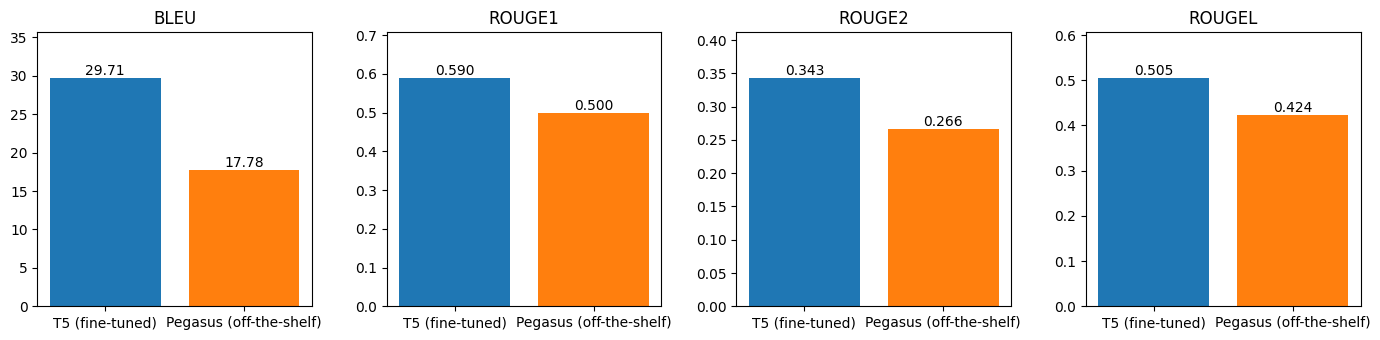

In [8]:
if summaries:
    metrics = ['bleu', 'rouge1', 'rouge2', 'rougeL']
    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 3.5))
    for ax, m in zip(axes, metrics):
        names = list(summaries.keys())
        vals = [summaries[n][m] for n in names]
        ax.bar(names, vals, color=['#1f77b4', '#ff7f0e'][:len(names)])
        ax.set_title(m.upper())
        ax.set_ylim(0, max(vals) * 1.2 if vals else 1)
        for i, v in enumerate(vals):
            ax.text(i, v, f'{v:.3f}' if m != 'bleu' else f'{v:.2f}',
                    ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
else:
    print('No eval summaries available yet; skipping chart.')

## Notes & qualitative analysis

_(Fill in after running the cells.)_

- **Faithfulness vs novelty:** which model rewrites more aggressively? Which is closer to verbatim?
- **Long inputs:** does Pegasus handle the longer prompts (e.g. the qubits sentence) better than T5-small?
- **Failure modes:** any prompts where one model echoed the input or produced grammatical mistakes?
- **Latency / size trade-off:** T5-small is ~5x smaller and faster; is the quality gap small enough to prefer it for deployment?